In [155]:
import re
import pandas as pd
import numpy as np

from pathlib import Path

from pythainlp.tokenize import word_detokenize
from tqdm import tqdm_notebook

import seaborn as sns


In [156]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = "./thsarabunnew-webfont.ttf"
fm.fontManager.addfont(font_path)

plt.rcParams['font.family'] = 'TH Sarabun New'

In [157]:
path_folder = Path("data/")

In [158]:
import chardet

rawdata = open(path_folder / "train.txt", 'rb').read()
result = chardet.detect(rawdata)

print(result)

{'encoding': 'utf-8', 'confidence': 0.99, 'language': ''}


In [159]:
texts = []
labels = []

with open(path_folder / "train.txt", encoding="utf-8") as f:
    for line in f:
        texts.append(line.strip())

with open(path_folder / "train_label.txt", encoding="utf-8") as f:
    for line in f:
        labels.append(line.strip())

df = pd.DataFrame({ "category": labels, "texts": texts })
del texts
del labels

df.to_csv("_train.csv", index=False)

df.shape

(24063, 2)

In [160]:
texts = []
labels = []

with open(path_folder / "test.txt",encoding="utf-8") as f:
    for line in f:
        texts.append(line.strip())

test_df = pd.DataFrame({ "category": "neu", "texts": texts })
del texts
del labels

test_df.to_csv("_test.csv", index=False)
test_df.shape

(2674, 2)

In [161]:
df.describe()

,category,texts
count,24063,24063
unique,4,24014
top,neu,#ERROR!
freq,13105,31


In [162]:
df.head()

,category,texts
0,neu,ประเทศเราผลิตและส่งออกยาสูบเยอะสุดในโลกจิงป่าวคับ
1,neu,คะ
2,neg,อิเหี้ยออมทำกูอยากกินเอ็มเค
3,neu,😅😅😅
4,neu,สวัสดีวันพุธ แนน อะไรนะ


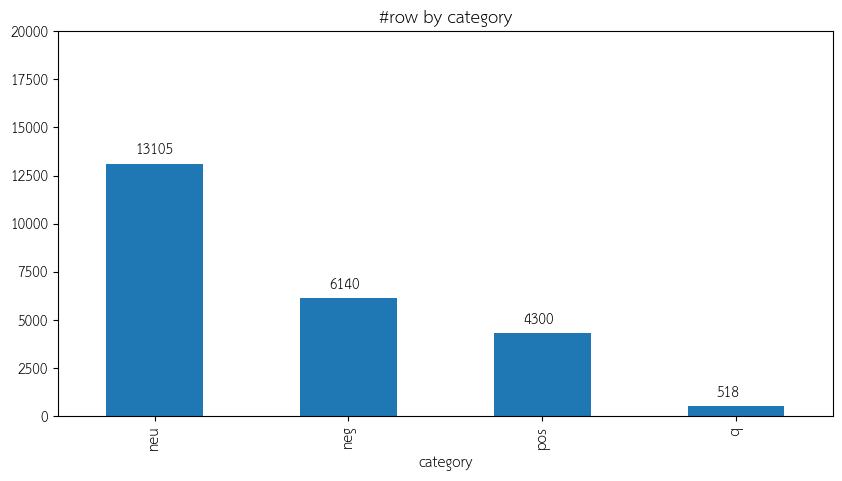

In [163]:
row_count_by_category = df.category.value_counts()
ax = row_count_by_category.plot(kind="bar", title="#row by category", figsize=(10, 5))
ax.set_ylim(0, 20000)
for i, label in enumerate(row_count_by_category):
    ax.annotate(str(label), (i-0.1, label + 500))

In [164]:
df["length"] = df["texts"].apply(word_detokenize).apply(len)
df.head()

,category,texts,length
0,neu,ประเทศเราผลิตและส่งออกยาสูบเยอะสุดในโลกจิงป่าวคับ,49
1,neu,คะ,2
2,neg,อิเหี้ยออมทำกูอยากกินเอ็มเค,27
3,neu,😅😅😅,5
4,neu,สวัสดีวันพุธ แนน อะไรนะ,23


<Axes: >

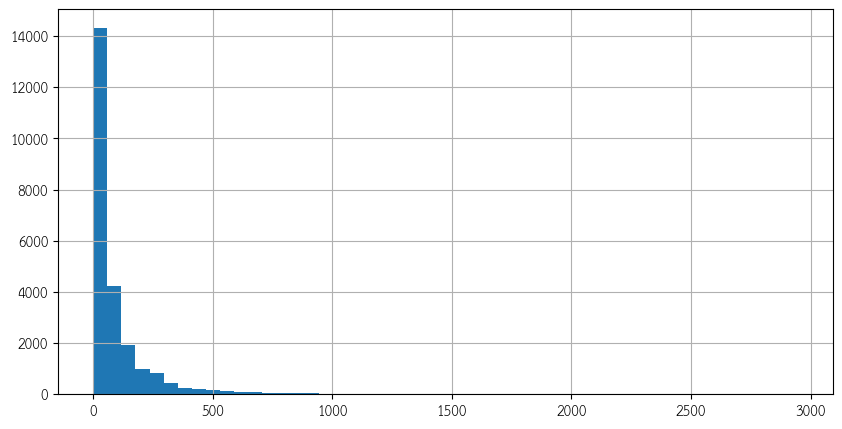

In [165]:
df["length"].hist(bins=50, figsize=(10, 5))

In [166]:
df["length"].describe()

count    24063.000000
mean       103.097162
std        179.406963
min          1.000000
25%         20.000000
50%         42.000000
75%        108.000000
max       2946.000000
Name: length, dtype: float64

In [167]:
df[df["length"] >= 740]

,category,texts,length
47,neg,ขออนุญาติ ติบริการของพนักงานทางร้านด้วยค่ะ #mk...,864
52,neu,DJ.ชมพู แจกฟรี! บัตร Chang music แจกอีกครั้งนะ...,818
124,neu,(‘GET 102.5’ ร่วมสร้างปรากฏการณ์เรืองแสงสุดยิ่...,918
141,neu,รพ.กรุงเทพพัทยา จัด Workshop : ไขความลับสุขภาพ...,1075
183,neu,จันทร์ Shock โลก The Return คืนนี้ ดีเจโอ๊ต ปร...,1349
...,...,...,...
23864,neu,"รอบ 8 คน ระทึก ""พุฒ อุบล"" ท้าชน ""จิ๋ว เชียงราย...",823
23983,neu,#เมนูเพื่อสุขภาพจากนักโภชนาการ ฟรุ๊ตสลัดเชื่อม...,955
23991,neu,ใช่ครับผม แต่จะมีบางสาขาเท่านั้นนะคร้าบตอนนี้ต...,826
24020,neu,เกร็ดความรู้ วิธีรักษาสิวแบบธรรมชาติด้วยใบสะเด...,1932


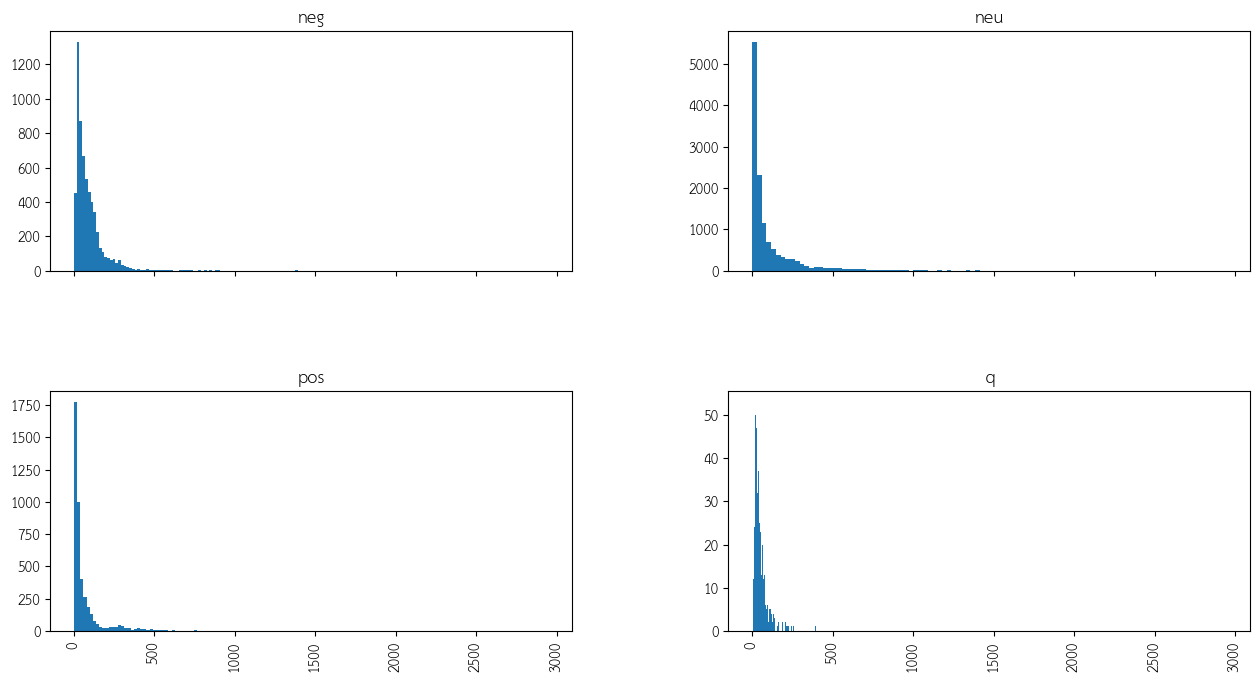

In [168]:
df.hist(column="length", by="category" , bins=100, figsize=(15, 8), sharex=True)
plt.show()

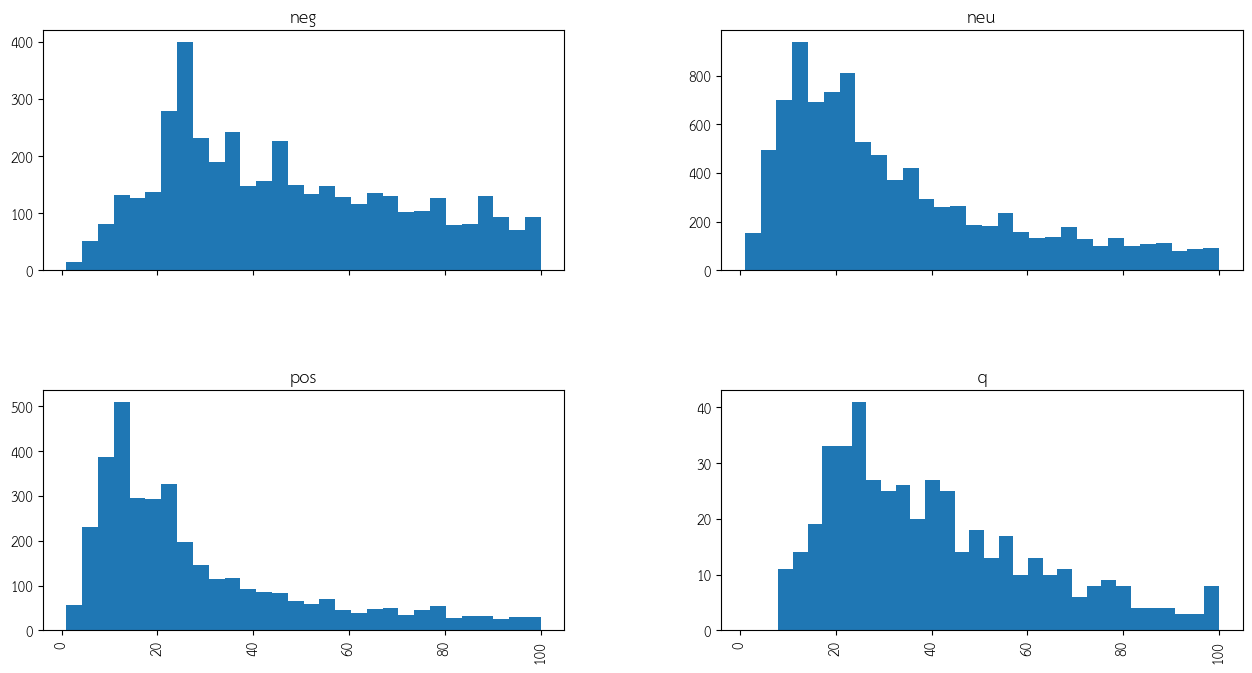

In [169]:
df[df["length"] <= 100].hist(column="length", by="category", bins=30, figsize=(15,8), sharex=True)
plt.show()

#   Preprocess

In [170]:
import string
import emoji
import numpy as np
from pythainlp.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

def process_text(text):
    nopunc = [char for char in text if char not in string.punctuation]
    nopunc = "".join(nopunc)
    
    return [word for word in word_tokenize(nopunc) if word and not re.search(pattern=r"\s+", string=word)]

def extract_url(text):
    URL_PATTERN = r"(https?:\/\/)?\.([\da-z-]+)\.([a-z\.]{2,6})([\/\w\.-]*)*\/?\S"
    return [url[1] for url in re.findall(pattern=URL_PATTERN, string=text.lower())]


def extract_emojis(text):
    return [c for c in text if c in emoji.EMOJI_DATA]

def extract_punc(text):
    return [char for char in text if char in string.punctuation]

def extract_hashtags(text):
    HASHTAG_PATTERN = r"#[a-zA-Z0-9ก-๙]+"
    return re.findall(pattern=HASHTAG_PATTERN, string=text)

if __name__ == "__main__":
    sample_text = "จันทร์ Shock โลก The Return คืนนี้ ดีเจโอ๊ต ปราโมทย์ เปิดบ้านต้อนรับดีเจคุณพ่อลูกหนึ่ง เจ็ม ณัฏฐ์ปวินท์ มาระเบิดความฮากับคำถามสุดช๊อกและของรางวัลสุดกวน 3-5 ทุ่มที่ EFM104.5 และชมสดพร้อมๆกันผ่าน Facebook Live & Youtube Live ลงทะเบียนเล่นเกมส์ได้แล้วตอนนี้ที่เบอร์ 02-222-2222 . สนับสนุนความ Shockkkkk โดย Centerpoint of Siam Square https://www.facebook.com/centerpointofsiamsquare BarBQ Plaza http://www.11street.co.th/store/MiniMallAction/getMiniMallHome.do?sellerHmpgUrl=barbqplaza MG http://mgcars.com/th/mg-models/mgzs/detail/overview รู้ใจดอทคอม https://www.roojai.com/ Traveloka https://www.traveloka.com/th-th/?utm_source=THFlightHotel&utm_medium=radio&utm_campaign=EOY-011117 CP https://www.facebook.com/dimsum.jadedragon/ Enchanter https://www.facebook.com/EnchanteurThailand/ #จันทร์ShockโลกTheReturn"
    
    print("คำที่ถูกตัด: ", process_text(sample_text))
    print("URL:       ", extract_url(sample_text))
    print("อิโมจิ:      ", extract_emojis(sample_text))
    print("วรรคตอน:   ", extract_punc(sample_text))
    print("แฮชแท็ก:    ", extract_hashtags(sample_text))

คำที่ถูกตัด:  ['จันทร์', 'Shock', 'โลก', 'The', 'Return', 'คืนนี้', 'ดีเจ', 'โอ๊ต', 'ปราโมทย์', 'เปิด', 'บ้าน', 'ต้อนรับ', 'ดีเจ', 'คุณพ่อ', 'ลูก', 'หนึ่ง', 'เจ็ม', 'ณัฏฐ์ปวินท์', 'มา', 'ระเบิด', 'ความ', 'ฮา', 'กับ', 'คำถาม', 'สุด', 'ช๊อก', 'และ', 'ของรางวัล', 'สุด', 'กวน', '35', 'ทุ่ม', 'ที่', 'EFM', '1045', 'และ', 'ชม', 'สด', 'พร้อม', 'ๆ', 'กัน', 'ผ่าน', 'Facebook', 'Live', 'Youtube', 'Live', 'ลงทะเบียน', 'เล่น', 'เกมส์', 'ได้', 'แล้ว', 'ตอนนี้', 'ที่', 'เบอร์', '022222222', 'สนับสนุน', 'ความ', 'Shockkkkk', 'โดย', 'Centerpoint', 'of', 'Siam', 'Square', 'httpswwwfacebookcomcenterpointofsiamsquare', 'BarBQ', 'Plaza', 'httpwww', '11', 'streetcothstoreMiniMallActiongetMiniMallHomedosellerHmpgUrlbarbqplaza', 'MG', 'httpmgcarscomthmgmodelsmgzsdetailoverview', 'รู้ใจ', 'ดอทคอม', 'httpswwwroojaicom', 'Traveloka', 'httpswwwtravelokacomththutmsourceTHFlightHotelutmmediumradioutmcampaignEOY', '011117', 'CP', 'httpswwwfacebookcomdimsumjadedragon', 'Enchanter', 'httpswwwfacebookcomEnchanteurThail

In [171]:
def top_feats(row, features, top_n=25):
    ''' Get top n tfidf values in row and return them with their corresponding feature names.'''

    topn_ids = np.argsort(row)[::-1][:top_n]
    top_feats = [(features[i], row[i]) for i in topn_ids]
    df = pd.DataFrame(top_feats)
    df.columns = ["feature", "score"]

    return df


In [172]:
def top_mean_feats(Xtr, features, grp_ids=None, min_tfidf=0.1, top_n=25):
    ''' Return the top n features that on average are most important amongst documents in rows
        indentified by indices in grp_ids. '''

    if grp_ids:
        D = Xtr[grp_ids].toarray()
    else:
        D = Xtr.toarray()

    D[D < min_tfidf] = 0
    tfidf_means = np.mean(D, axis=0)

    return top_feats(tfidf_means, features, top_n)

In [173]:
def top_feats_by_class(Xtr, y, features, min_tfidf=0.1, top_n=25):
    ''' Return a list of dfs, where each df holds top_n features and their mean tfidf value
        calculated across documents with the same class label. '''

    dfs = []
    labels = np.unique(y)

    for label in labels:
        ids = np.where(y==label)
        feats_df = top_mean_feats(Xtr, features, ids, min_tfidf=min_tfidf, top_n=top_n)
        feats_df.label = label
        dfs.append(feats_df)

    return dfs

In [174]:
def plot_classfeats_h(dfs, score_name=''):
    ''' Plot the data frames returned by the function plot_tfidf_classfeats(). '''

    fig = plt.figure(figsize=(12, 9), facecolor="w")
    x = np.arange(len(dfs[0]))

    for i, df in enumerate(dfs):
        ax = fig.add_subplot(1, len(dfs), i+1)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.set_frame_on(False)
        ax.get_xaxis().tick_bottom()
        ax.get_yaxis().tick_left()
        ax.set_xlabel(f"Mean {score_name} Score", labelpad=16, fontsize=14)
        ax.set_title("label = " + str(df.label), fontsize=16)
        ax.ticklabel_format(axis='x', style='sci', scilimits=(-2,2))
        ax.barh(x, df.score, align='center', color='#3F5D7D')
        ax.set_yticks(x)
        ax.set_ylim([-1, x[-1]+1])
        ax.invert_yaxis()
        yticks = ax.set_yticklabels(df.feature)
        plt.subplots_adjust(bottom=0.09, right=0.97, left=0.15, top=0.95, wspace=0.52)

    plt.show()

In [175]:
def show_classfeats(
    df,
    vectorizer,
    analyzer,
    score_name='',
    text_col='texts',
    class_col='category',
    is_emoji=False,
    smooth=True
):

    vec = vectorizer(
            analyzer=analyzer,
            smooth_idf=smooth
    )

    mat = vec.fit_transform(df[text_col])

    dfs = top_feats_by_class(
        mat,
        df[class_col],
        vec.get_feature_names_out()
    )

    if is_emoji:
        for dataframe in dfs:
            dataframe.columns = [
                dataframe.label,
                'tfidf_' + dataframe.label
            ]
        return pd.concat(dfs, axis=1)

    else:
        plot_classfeats_h(
            dfs,
            score_name=score_name
        )

# TF-IDF


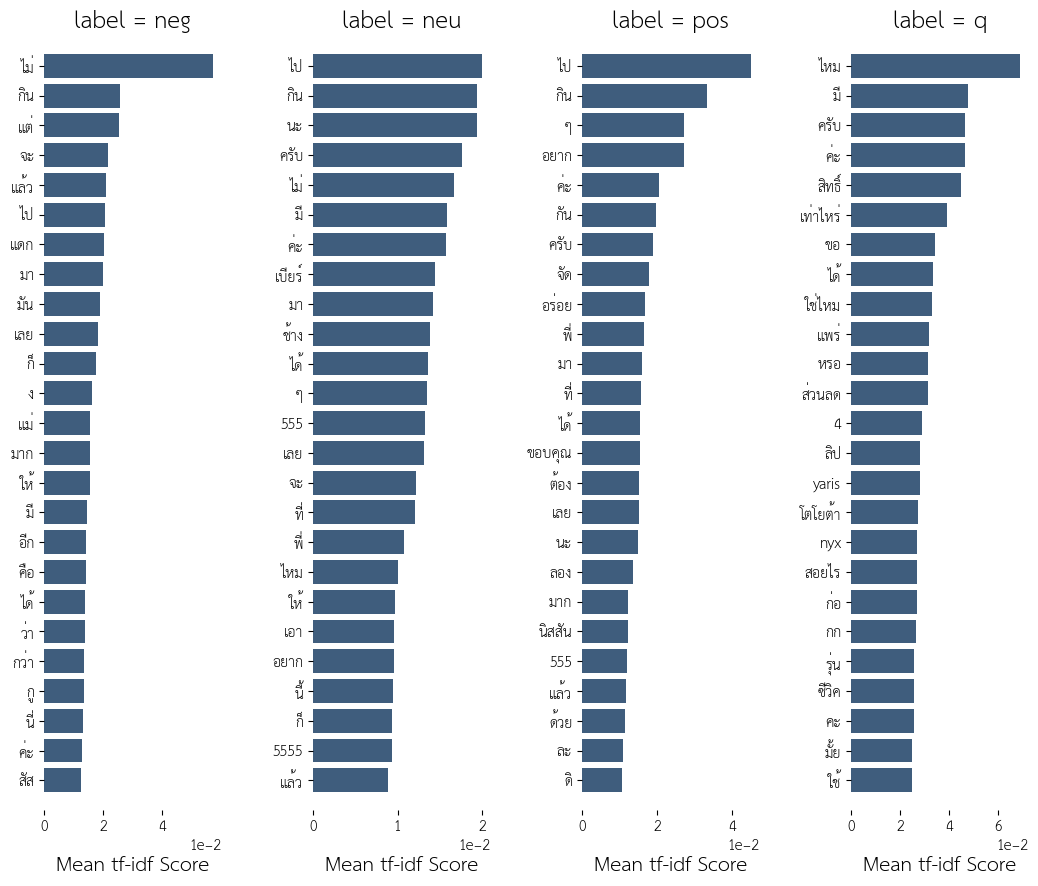

In [176]:
show_classfeats(
    df=df[:1000],
    vectorizer=TfidfVectorizer,
    analyzer=process_text,
    score_name="tf-idf",
)

In [177]:
show_classfeats(
    df=df,
    vectorizer=TfidfVectorizer,
    score_name="tf-idf",
    analyzer=extract_emojis,
    is_emoji=True
)

,neg,tfidf_neg,neu,tfidf_neu,pos,tfidf_pos,q,tfidf_q
0,😂,0.017554,😂,0.007692,😂,0.013105,😂,0.006542
1,😭,0.010715,😍,0.004362,😍,0.010567,😍,0.003861
2,🤣,0.003469,❤,0.003273,😁,0.007655,🤔,0.003861
3,😅,0.003061,😁,0.003214,😘,0.006371,😭,0.003709
4,😢,0.002805,🏻,0.002964,❤,0.005362,😋,0.001931
5,🙄,0.002556,👉,0.002960,😋,0.004706,😮,0.001931
6,😡,0.002058,😊,0.002883,😊,0.004368,😩,0.001931
7,😁,0.002024,🤣,0.002870,😆,0.003676,😙,0.001931
8,😑,0.001852,🙏,0.002357,🤤,0.003664,👀,0.001931
9,😒,0.001602,📍,0.002259,👍,0.003334,🎻,0.000000


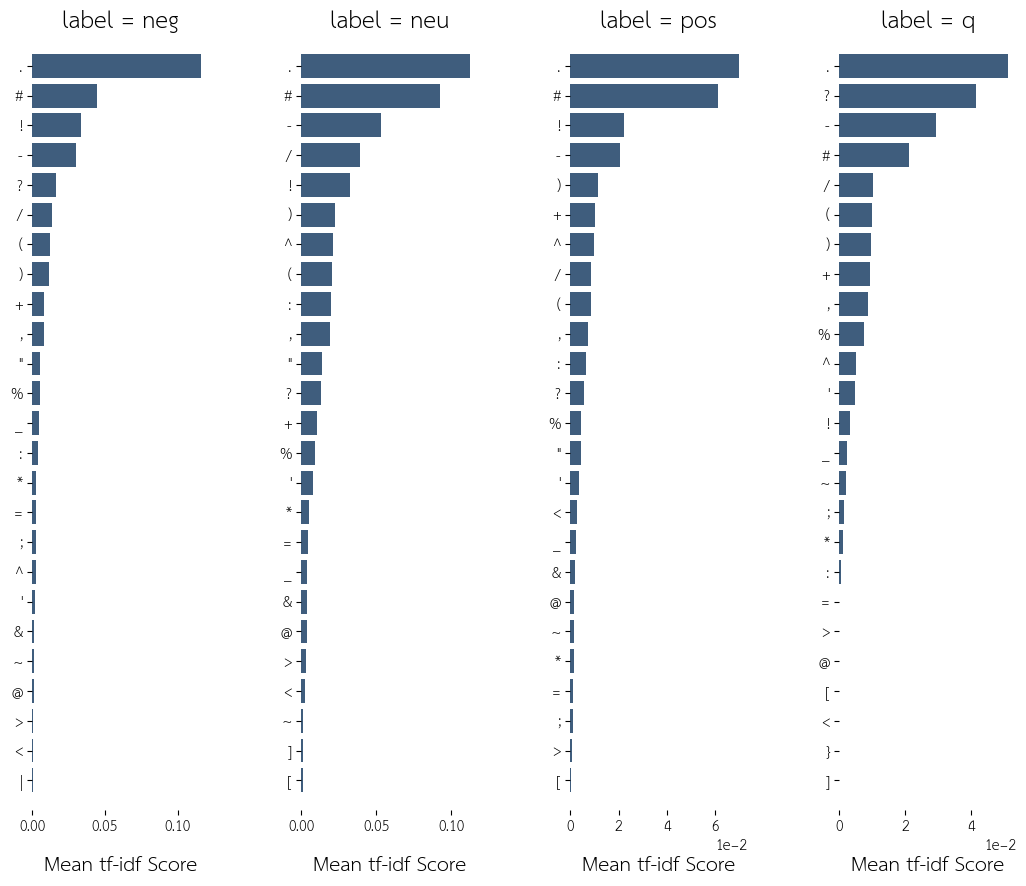

In [178]:
show_classfeats(df=df, vectorizer=TfidfVectorizer, score_name="tf-idf", analyzer=extract_punc)

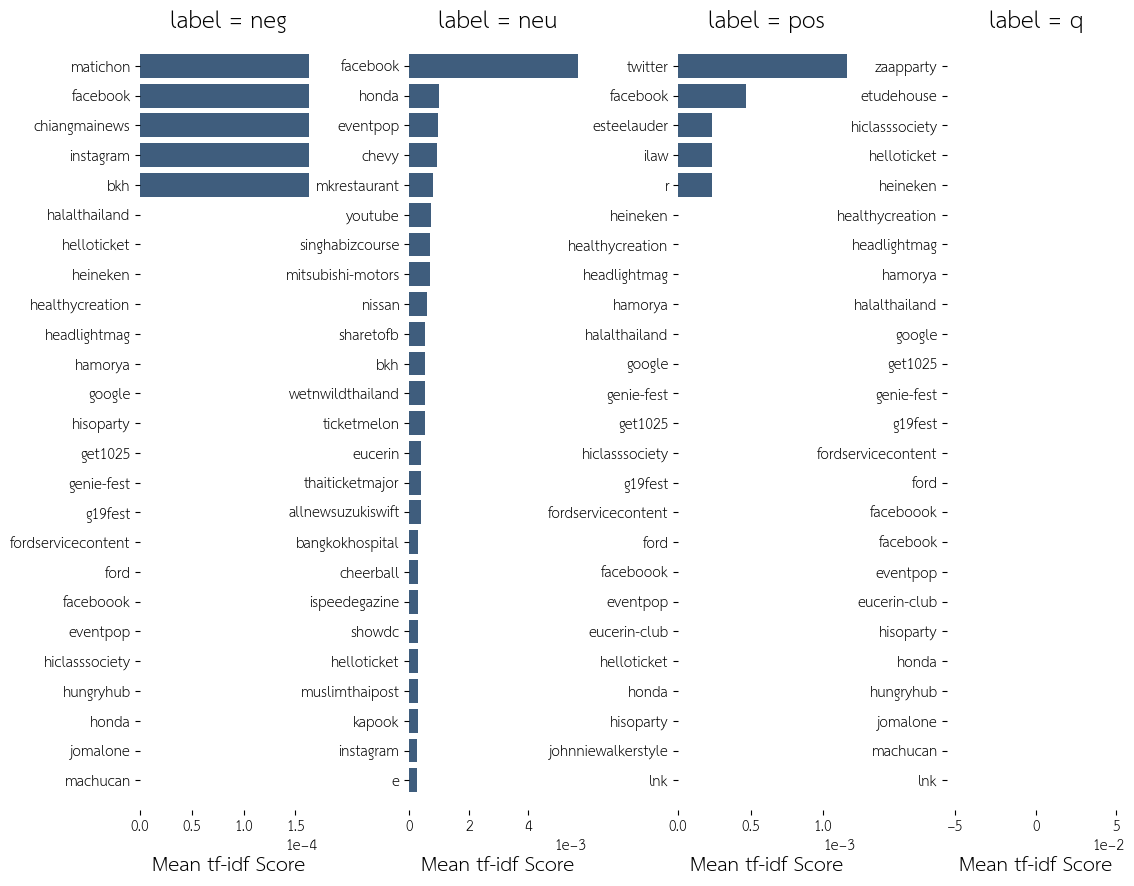

In [179]:
show_classfeats(df=df, vectorizer=TfidfVectorizer, score_name="tf-idf", analyzer=extract_url)

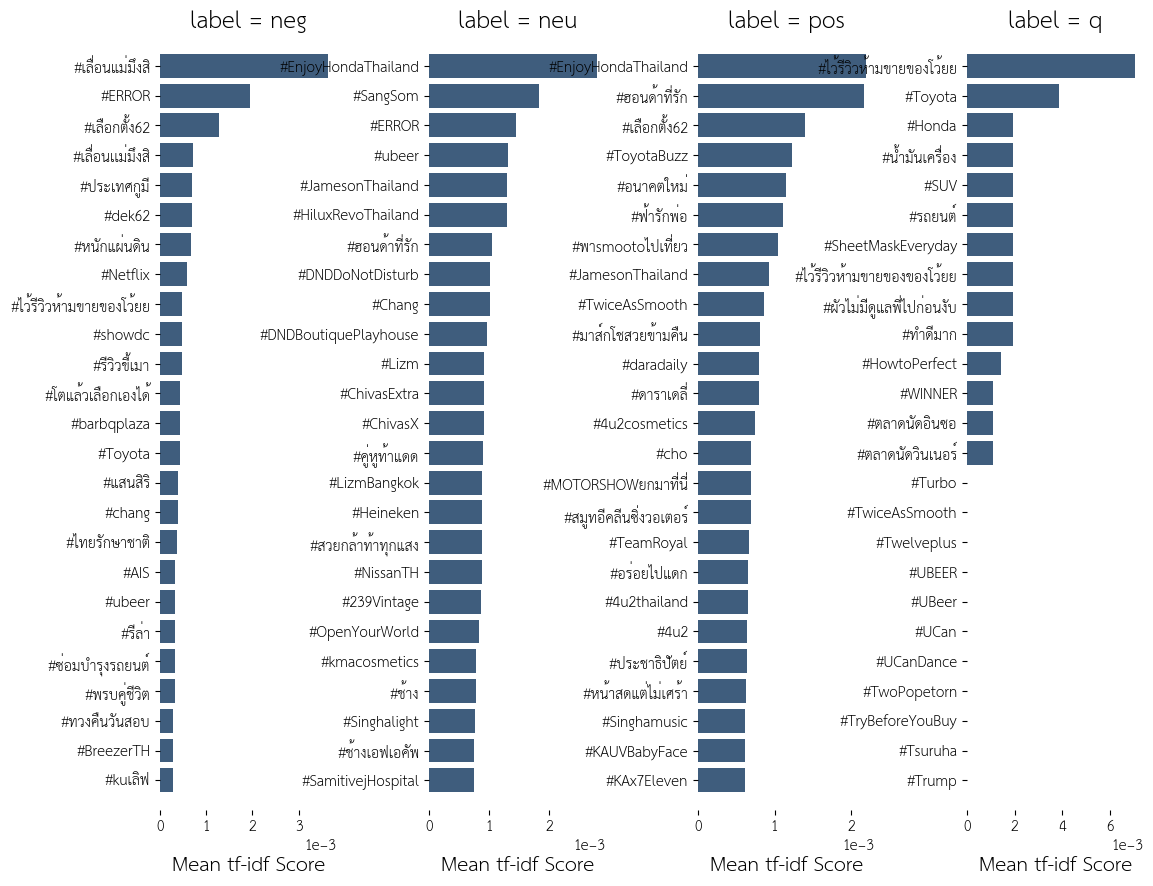

In [180]:
show_classfeats(df=df, vectorizer=TfidfVectorizer, score_name="tf-idf", analyzer=extract_hashtags)

# Neutral, Positive, Negative

In [181]:
neu_df = df[df.category == "neu"].sample(5000)
neu_df.head()

,category,texts,length
443,neu,กินลูกชิ้นปิ้งข้างทางไม้ละ 20 บาท ละกัน,41
8254,neu,เหลือๆ,7
4298,neu,ไปจองนิสสันพิจิตรมาละ แต่ไม่ผ่าน ไม่ดัน เฮ้อ,44
2278,neu,ผิวขาดน้ำ ไม่ได้หมายถึงผิวแห้งเพียงอย่างเดียว ...,508
22860,neu,เชียงราย = เรียงราย555,26


In [182]:
pos_df = df[df.category == "pos"]
pos_df.head()

,category,texts,length
10,pos,สนใจ ฟอจูนเนอร์ สีขาวครับ,25
16,pos,ไปดิ..รอไร,13
19,pos,อยากกินบาบีก้อนหรอ555555,30
22,pos,ต้องไปลองกันนะ,14
25,pos,ขอให้ SHEENe มีกิจการรุ่งเรือง ขายดีๆ ยอดไลท์เ...,136


In [183]:
neg_df = df[df.category == "neg"]
neg_df.head()

,category,texts,length
2,neg,อิเหี้ยออมทำกูอยากกินเอ็มเค,27
6,neg,เน็ตควายมากกูพูดจริงเสียดายตังค์ที่ติดตั้งเน็ต...,478
8,neg,เหล้าเบลล์รสชาติเหี้ยสุด จะไม่แดกอีกละ,38
11,neg,ลิปมันของเเบร์น Mistine ราคากลาง ๆ ไม่แพงมาก ร...,104
12,neg,ทำไมมันไม่มีโปรให้เร๊าาาาาา,27


In [184]:
sentiment_df = pd.concat([neg_df, pos_df, neu_df])
sentiment_df = sentiment_df.reset_index(drop=True)
sentiment_df.groupby("category").texts.describe()


,count,unique,top,freq
category,,,,
neg,6140,6129,#ERROR!,12
neu,5000,4993,#ERROR!,8
pos,4300,4300,สนใจ ฟอจูนเนอร์ สีขาวครับ,1


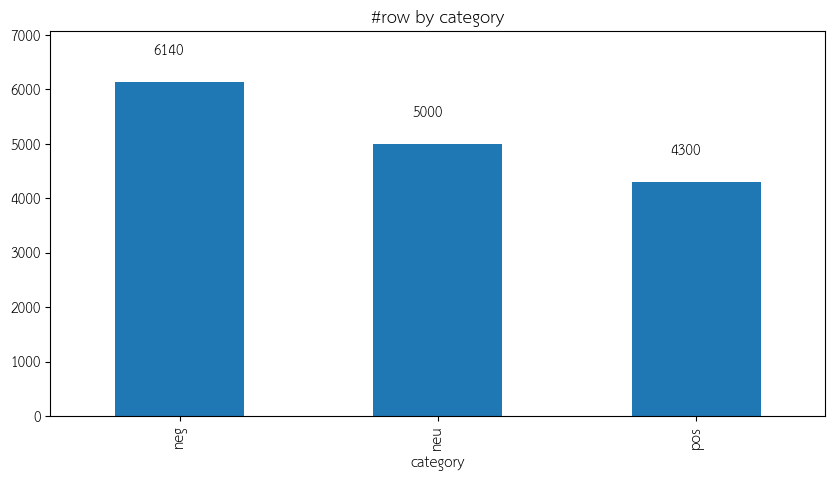

In [185]:
row_count_by_category = sentiment_df.category.value_counts()
ax = row_count_by_category.plot(kind="bar", title="#row by category", figsize=(10, 5))
ax.set_ylim(0, row_count_by_category.max() + row_count_by_category.std())
for i, label in enumerate(row_count_by_category):
    ax.annotate(str(label), (i-0.1, label + 500))

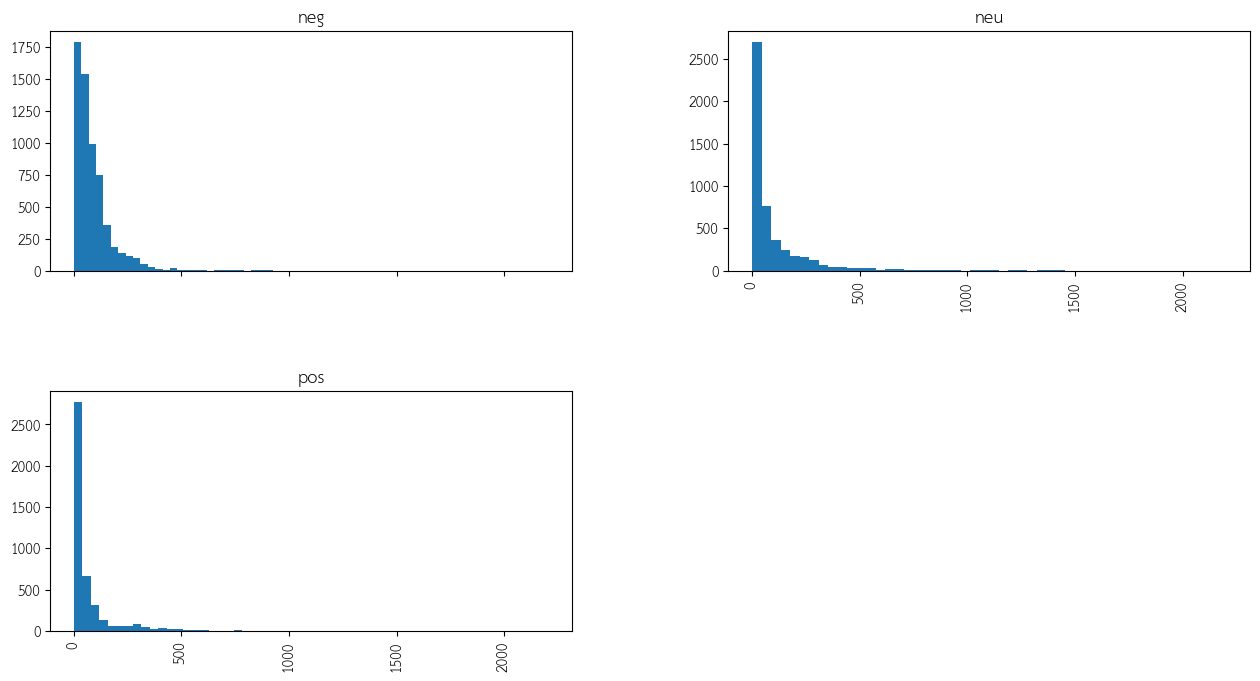

In [186]:
sentiment_df.hist(column="length", by="category", bins=50, figsize=(15, 8), sharex=True)
plt.show()

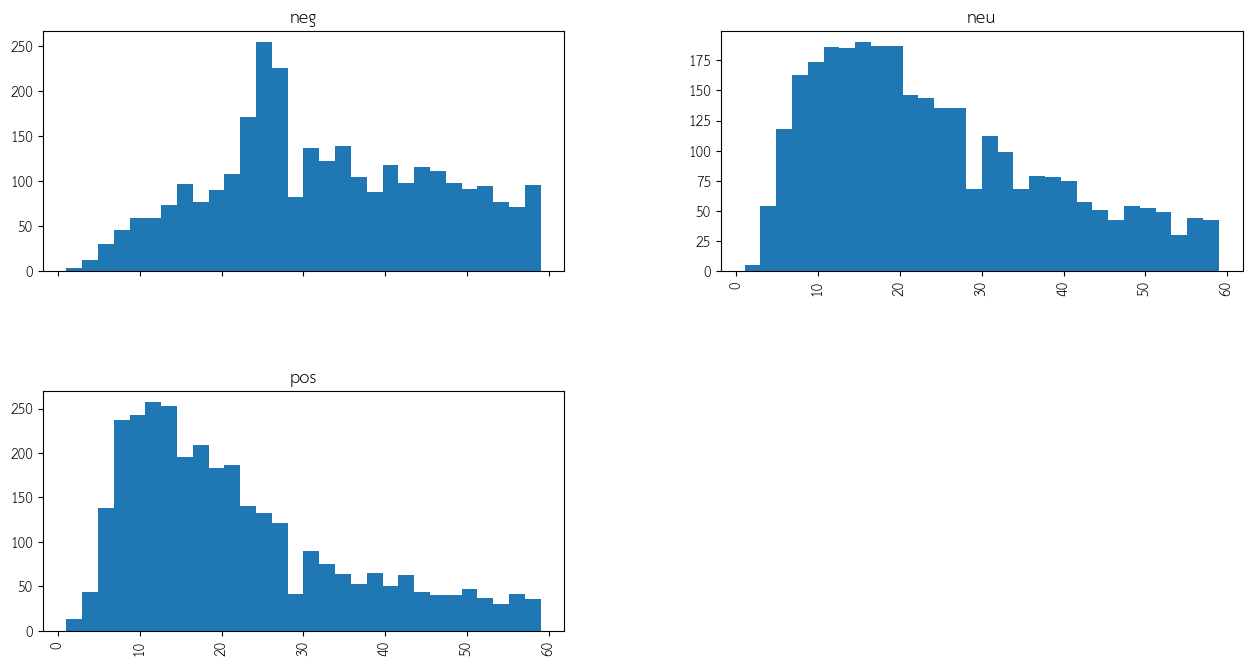

In [187]:
sentiment_df[sentiment_df.length < 60].hist(column="length", by="category", bins=30, figsize=(15, 8), sharex=True)
plt.show()

# Classification
- ML Classification
- DL Classification

In [188]:
class_names = np.unique(sentiment_df.category).tolist()
print(class_names)

['neg', 'neu', 'pos']


# Data Split

In [189]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(sentiment_df["texts"], sentiment_df["category"], test_size=0.20, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(12352,) (3088,) (12352,) (3088,)


In [190]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.naive_bayes import MultinomialNB

text_clf = Pipeline([
    ("vect", CountVectorizer(tokenizer=process_text, ngram_range=(1,2))),
    ("tfidf", TfidfTransformer()),
    ("clf", MultinomialNB(alpha=0.001)),
])

text_clf.fit(X_train, y_train)
text_clf.score(X_test, y_test)


C:\Users\CyberLAB02\AppData\Roaming\Python\Python310\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


0.6450777202072538

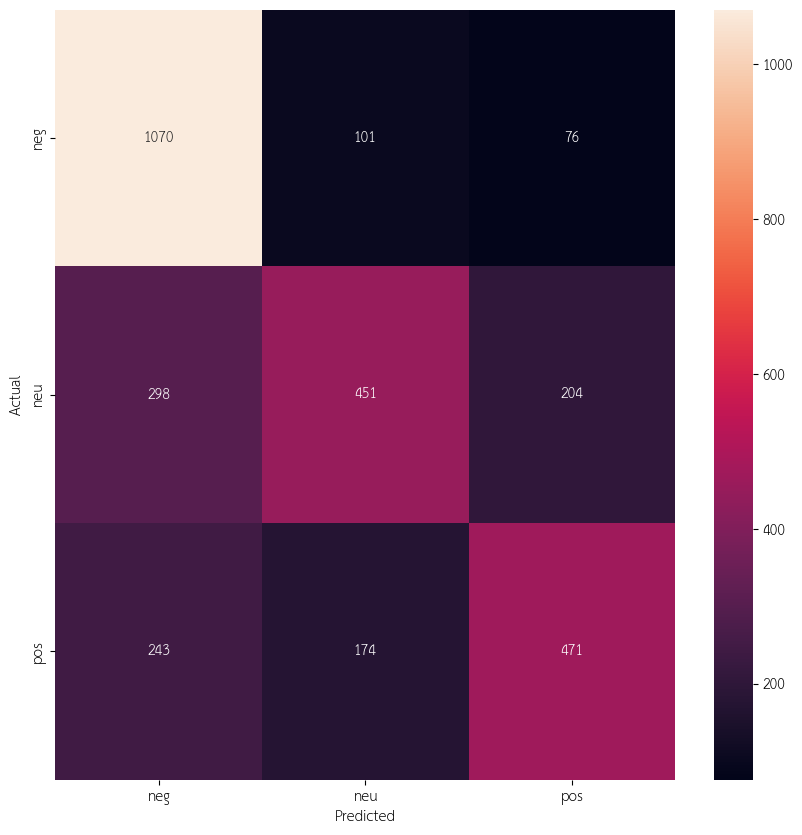

In [191]:
from sklearn.metrics import confusion_matrix

conf_mat = confusion_matrix(y_test, text_clf.predict(X_test))
fig, ax = plt.subplots(figsize=(10,10))
sns.heatmap(conf_mat, annot=True, fmt="d",
            xticklabels=class_names, yticklabels=class_names)
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

In [192]:
from sklearn.calibration import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.naive_bayes import MultinomialNB





Pipeline([
 ("vect", CountVectorizer(tokenizer=process_text)),
 ("tfidf", TfidfTransformer()),
 ("clf", LinearSVC(max_iter=10))
])

text_clf.fit(X_train, y_train)
text_clf.score(X_test, y_test)

C:\Users\CyberLAB02\AppData\Roaming\Python\Python310\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


0.6450777202072538

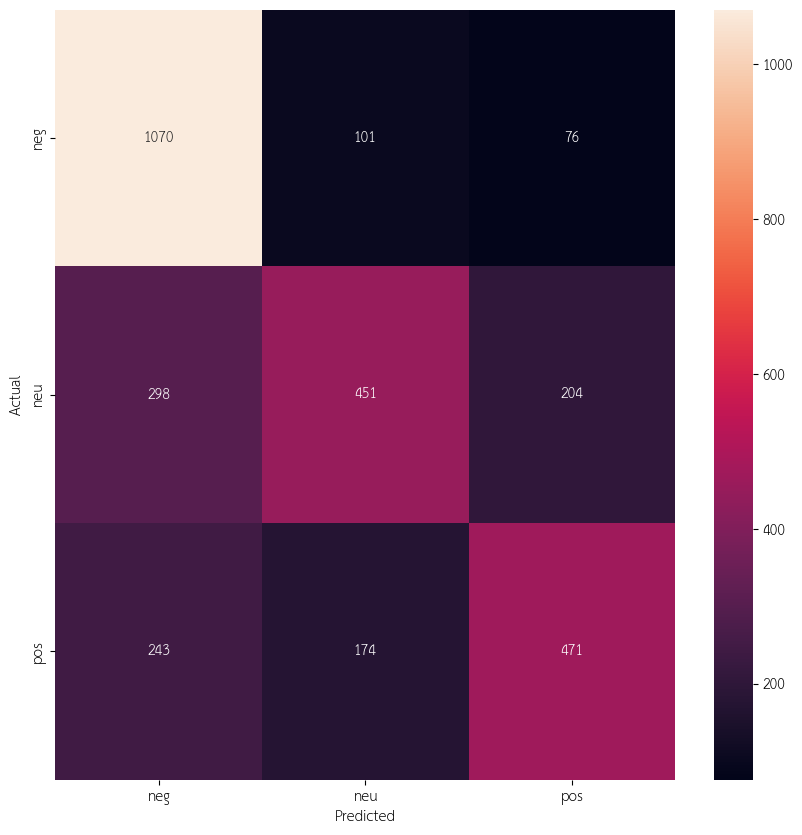

In [193]:
from sklearn.metrics import confusion_matrix

conf_mat = confusion_matrix(y_test, text_clf.predict(X_test))
fig, ax = plt.subplots(figsize=(10,10))
sns.heatmap(conf_mat, annot=True, fmt="d",
            xticklabels=class_names, yticklabels=class_names)
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()